In [1]:
from PIL import Image

#img = Image.open("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/image/vanillaSoftMax.webp")
#img = img.convert("RGB")
#img.thumbnail((400, 400))  # max 800x800 pixels
#img.save("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/image/vanillaSoftMax.png", format="png", quality=100)

In [40]:
import os
import torch
from IPython import get_ipython # type: ignore

def get_runtime_info():
    # 1) Détecter si on est sur Google Colab
    try:
        in_colab = 'google.colab' in str(get_ipython()) # type: ignore
    except NameError:
        in_colab = False

    # 2) Vérifier CUDA (GPU NVIDIA, typiquement sur Colab)
    cuda_available = torch.cuda.is_available()

    # 3) Vérifier MPS (GPU Apple Silicon, typiquement en local sur Mac)
    mps_available = getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available()

    if in_colab and cuda_available:
        device = torch.device("cuda")
        location = "colab_cuda"
    elif mps_available:
        device = torch.device("mps")
        location = "local_mps"
    else:
        device = torch.device("cpu")
        location = "cpu"

    return {
        "in_colab": in_colab,
        "cuda_available": cuda_available,
        "mps_available": mps_available,
        "device": device,
        "location": location,  # "colab_cuda", "local_mps" ou "cpu"
    }

info = get_runtime_info()
print("device",info["device"])
device=info["device"]

device mps


# __`Speech Command Recognition`__ 

__NOM ETUDIANT : Gérard BENITAH__

lauriane.bompay@irit.fr

:::
__Présentation de l'article__.   
L’article présente un système de reconnaissance de commandes vocales, à faible latence et faible empreinte mémoire, basé sur différents modèles de réseaux de neurones (softmax simple, dnn et cnn) appliqués au Speech Commands Dataset de Google (65 000 fichiers WAV, 30 mots, 1 s chacun).
Les auteurs extraient des caractéristiques MFCC sur des fenêtres de 30 ms (stride 10 ms), produisant des matrices 2D 98×40 qui servent d’entrée aux réseaux.

:::
:::
__Abstract__
Projet visant à construire un système de reconnaissance de commandes vocales précis, léger et à faible latence, capable de détecter des mots-clés prédéfinis.
À partir du jeu de données Speech Commands de Google, différentes architectures sont testées : 
 - modèle softmax simple, 
 - réseau de neurones profond (dnn) et 
 - réseau de neurones convolutif (cnn).
Le cnn surpasse les deux autres modèles et atteint une exactitude de 95,1% sur 6 étiquettes.
:::
:::
__Résumée de l’introduction__.  
L’interaction vocale sur mobile (Google Now, Siri, “Ok Google”) repose sur la détection de mots-clés (keyword spotting, KWS), pratique pour les scénarios mains libres et les situations de conduite ou d’urgence.
Comme ces systèmes tournent sur smartphone ou tablette, ils doivent être rapides, peu gourmands en mémoire et en calcul, d’où la recherche d’architectures compactes.
Le système classifie chaque clip d’une seconde comme « silence », « mot inconnu » ou l’un des mots-clés prédéfinis (par ex. yes/no, up/down/left/right, stop/go), puis utilise les trois modèles (softmax, dnn, cnn) pour produire une probabilité et un label final.
:::
:::
__Résumée de la partie modèles et résultats__.   
 - `Vanilla softmax` : une seule couche entièrement connectée avec softmax, très rapide mais peu précise (environ 56% de précision test).

 - `dnn` : 3 couches cachées de 128 neurones avec ReLU et dropout, meilleure précision (≈72%) mais plus de paramètres et de calcul.

 - `cnn` : 2 couches de convolution, couches de pooling, dropout, couche linéaire basse dimension, puis fully-connected + softmax, moins de 250 k paramètres et meilleure performance (≈94,5% test, meilleure précision, rappel, AUC).
:::

​

# `I Préparation des données`

In [3]:
#%pip install numpy scipy matplotlib tqdm 
#python -m pip install ipykernel
#%pip -q install scikit-learn

In [4]:
import torch, torchaudio
print(torch.__version__, torchaudio.__version__)

from torchaudio.datasets import SPEECHCOMMANDS

2.2.2 2.2.2


### `1.1 Technologie de repérage de mots-clés (KWS)`

:::
`Technologie de repérage de mots-clés (KWS) fournie une interface mains libres`
 - KEYWORDS = ["up", "down", "left", "right"]
 - SILENCE_LABEL = "_silence_"
 - UNKNOWN_LABEL = "_unknown_" #  the background volume is 0.1 and its frequency is 0.8.
:::


### `1.2 Rappels sur les splits Speech Commands`

In [ ]:
import os
import random
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F
import torchaudio
import numpy as np

root_dir = "M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/data/speech_commands/"
# ------------------------------------------------------------------
# Mapping label texte -> label compact
# À adapter à ton mapping exact
# ------------------------------------------------------------------
KLASSES = ["down", "left", "right", "up", "silence", "unknown"]
CLASSES = ["down", "left", "right", "up", "_background_noise_"]
n_classes = len(KLASSES)

label2id = {c: i for i, c in enumerate(KLASSES)}
id2label = {v: k for k, v in label2id.items()}

def word_to_label(word_str: str) -> str:
    if word_str in KLASSES:
        return word_str
    elif word_str == "_background_noise_":
        return "silence"
    else:
        return "unknown"  # au cas où tu gardes d'autres mots
    
validate_every=400
num_steps=15000    

### `1.3. Construction des les listes validation et test filtrées par KEYWORDS`

In [6]:
import os

def load_list(path_txt):
    with open(path_txt) as f:
        return [line.strip() for line in f]

def filter_keywords(file_list, keywords): # right/bb05582b_nohash_3.wav
    out = []
    for rel_path in file_list:
        label = rel_path.split("/")[0]
        if label in keywords:
            out.append(rel_path)       
    return out

### `1.4. Lister tous les fichiers des 4 mots + bruit`
:::
Pour les 4 mots « normaux », tu utiliseras les fichiers exactement comme down/xxx.wav, etc. Pour le bruit, tu ne prendras pas directement les gros WAV, tu les utiliseras plus tard pour générer des segments de 1 s.
:::

In [7]:
#def add_Noise2List(train_files, val_files, test_files):
def TrainList_and_add_Noise2Lists():
    for kw in CLASSES:
        class_dir = os.path.join(root_dir, kw)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if not fname.endswith(".wav"):
                continue
            rel_path = f"{kw}/{fname}"
            if kw == "_background_noise_":
                train_files.extend([rel_path] * 100) 
                val_files.extend([rel_path] * 15)  
                test_files.extend([rel_path] * 15)   
            if (rel_path not in val_files) and (rel_path not in test_files):
                train_files.extend([rel_path])        
    return train_files, val_files, test_files

train_files = []  

val_files = filter_keywords(load_list(os.path.join(root_dir, "validation_list.txt")), CLASSES)
test_files = filter_keywords(load_list(os.path.join(root_dir, "testing_list.txt")), CLASSES)                 
train_files, val_files, test_files = TrainList_and_add_Noise2Lists()            

### `1.5 Split train / val / test pour les 4 mots`

__`Rappel MFCC = pipeline un peu plus long :`__
 - Mel‑spectrogram interne (avec n_fft=512, n_mels=40, mêmes win/hop).
 - Passage au log (log‑énergie Mel).
 - DCT (transformée en cosinus) sur l’axe fréquence pour obtenir les coefficients cepstraux.
 - On ne garde que les premiers coefficients n_mfcc (e.g. 40).

`Conséquence :`
 - MelSpectrogram → features de forme (time, n_mels) avec beaucoup de détails spectraux.
 - MFCC → features de forme (time, n_mfcc) plus compacts et décorrelés, 
 - typiquement mieux adaptés à des modèles « classiques » (GMM‑HMM, MLP, RNN légers) et souvent utilisés en reconnaissance de parole.

__`Pourquoi prenons nous les deux répsentations :`__ 
 - le train_transform = AT.MelSpectrogram(...), pour un pipeline spectrogrammes (par ex. cnn 2D sur Mel‑spectrogrammes).
 - la classe WavMFCCDataset est, conçue pour un pipeline MFCC (feature vector 98×40).

__`Choix de la famille de features :`__

`Si le modèle attend des MFCC 2D (98×40):`  
 - on utilise WavMFCCDataset avec self.mfcc_transform et pas les MelSpectrogram externes.
 - Si au contraire on veut travailler en Mel‑spectrogrammes purs, 
 - il faut abandonner MFCC et passer directement par MelSpectrogram (+ éventuellement AmplitudeToDB).

__`Conclusion`__ : 
 - Ces deux blocs représentent deux choix de représentation. 
 - Pour ton TP actuel, vu ta classe, le plus cohérent est de rester en MFCC 

### `1.6 Chargement des WAV et extraction MFCC`

 - parcourt une arborescence de WAV (type Speech Commands) ;
 - convertit chaque fichier en MFCC fixes 98×40 ;
 - remappe les dossiers/mots en labels compacts silence / keywords / unknown.

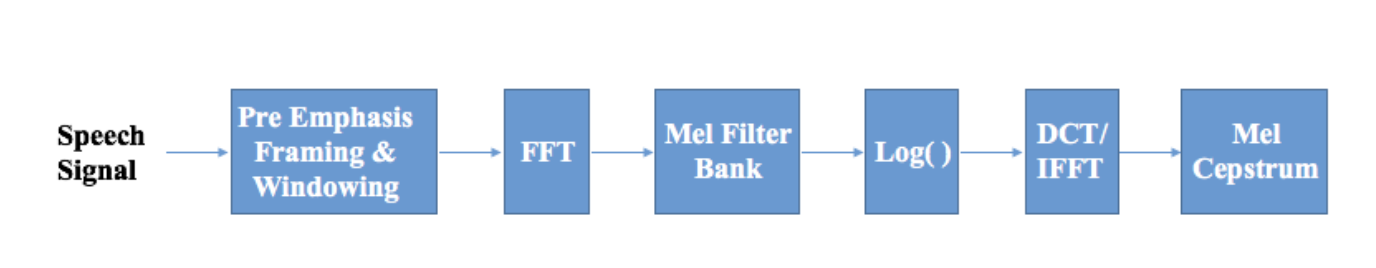

In [8]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/image/mfcc.png",width=700))

On utilise torchaudio.transforms.MFCC, qui encapsule : 

 - pré‑accentuation → fenêtrage → FFT → banc de filtres Mel → log → DCT → Mel Cepstrum / MFCC, 

In [ ]:
# ------------------------------------------------------------------
# Dataset MFCC à partir d'une liste de chemins relatifs
#   - gère les mots "normaux" et le bruit de fond
#   - pour le bruit: extrait des segments aléatoires de 1 s
# ------------------------------------------------------------------
class WavMFCCDataset(Dataset):
    def __init__(
        self,
        root_dir,
        file_list,          # liste de chemins relatifs: label/xxx.wav (incluant _background_noise_)
        sample_rate=16000,
        n_mfcc=40,
        win_length_ms=30,
        hop_length_ms=10,
        target_T=98,        # nombre de frames temporelles (≈ 1 s avec 30 ms / 10 ms)
        one_sec_noise=True  # si True: pour _background_noise_, on prend un segment de 1 s
    ):
        """
        root_dir  : racine du dataset Speech Commands
        file_list : liste de chemins relatifs (label/filename.wav) pour ce split (train/val/test)
        """
        self.root_dir = root_dir
        self.sample_rate = sample_rate
        self.target_T = target_T
        self.one_sec_noise = one_sec_noise

        # Construire (chemin absolu, label_str)
        self.files = []
        for rel_path in file_list:
            label_str = rel_path.split("/")[0]
            full_path = os.path.join(root_dir, rel_path)
            self.files.append((full_path, label_str))

        # Paramètres MFCC en nombre d'échantillons
        win_length = int(sample_rate * win_length_ms / 1000)
        hop_length = int(sample_rate * hop_length_ms / 1000)

        self.mfcc_transform = torchaudio.transforms.MFCC(
            sample_rate=sample_rate,
            n_mfcc=n_mfcc,
            melkwargs={
                "win_length": win_length,
                "hop_length": hop_length,
                "center": True,
                "f_min": 20.0,
                "n_mels": 40,
                "n_fft": 512,
                "f_max": 8000.0,
            },
        )

    def __len__(self):
        return len(self.files)

    def _load_waveform(self, path, label_str):
        waveform, sr = torchaudio.load(path)  # (1, T)
        if sr != self.sample_rate:
            waveform = torchaudio.functional.resample(waveform, sr, self.sample_rate)

        # Cas spécial: bruit de fond -> échantillon 1 s aléatoire si demandé
        if self.one_sec_noise and label_str == "_background_noise_":
            num_samples = self.sample_rate  # 1 s
            total = waveform.size(1)
            if total > num_samples:
                start = random.randint(0, total - num_samples)
                waveform = waveform[:, start:start + num_samples]
            elif total < num_samples:
                # pad si < 1 s
                pad = num_samples - total
                waveform = F.pad(waveform, (0, pad))

        return waveform

    def __getitem__(self, idx):
        wav_path, label_str = self.files[idx]

        waveform = self._load_waveform(wav_path, label_str)  # (1, T)

        # MFCC: (1, n_mfcc, T_frames)
        mfcc = self.mfcc_transform(waveform)
        mfcc = mfcc.squeeze(0)  # (n_mfcc, T_frames)

        # Padding / troncature en temps à target_T
        T = mfcc.shape[1]
        if T < self.target_T:
            pad = self.target_T - T
            mfcc = F.pad(mfcc, (0, pad))
        else:
            mfcc = mfcc[:, :self.target_T]

        # mapping label texte -> label compact
        mapped = word_to_label(label_str)
        label_id = label2id[mapped]  # entier 0..len(CLASSES)-1

        # Retour (T, n_mfcc) = (98, 40) pour un réseau type cnn/RNN
        mfcc = mfcc.transpose(0, 1)  # (T, n_mfcc)

        return mfcc, label_id


### `1.7. Construire les 3 datasets complets (train/val/test)`

In [10]:
from torch.utils.data import DataLoader

# Datasets "bruit"
# TODO: fixer des tailles équilibrées
train_dataset = WavMFCCDataset(root_dir, train_files, one_sec_noise=True)
val_dataset   = WavMFCCDataset(root_dir, val_files,   one_sec_noise=True)
test_dataset  = WavMFCCDataset(root_dir, test_files,  one_sec_noise=True)

### `1.8. DataLoader`

In [11]:
# DataLoader 
train_loader = DataLoader(train_dataset, batch_size=64, num_workers=0, pin_memory=False, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, num_workers=0, pin_memory=False, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, num_workers=0, pin_memory=False, shuffle=False)

In [12]:
print(f"len train_loader : {train_loader.batch_size}, echantillon : {len(train_loader.dataset)}") #type: ignore
print(f"len val_loader : {val_loader.batch_size}, echantillon : {len(val_loader.dataset)}") #type: ignore
print(f"len test_loader : {test_loader.batch_size}, echantillon : {len(test_loader.dataset)}") #type: ignore

len train_loader : 64, echantillon : 12738
len val_loader : 64, echantillon : 1532
len test_loader : 64, echantillon : 1729


### `1.9 Nombre de classes`

In [13]:
countstrain = {k: 0 for k in KLASSES}
countsvalid = {k: 0 for k in KLASSES}
countstest = {k: 0 for k in KLASSES}

for p in train_files:
    countstrain[word_to_label(p.split('/')[0])] += 1

for p in val_files:
    countsvalid[word_to_label(p.split('/')[0])] += 1

for p in test_files:
    countstest[word_to_label(p.split('/')[0])] += 1

print("count train class items:", countstrain)
print("count valid  class items:", countsvalid)
print("count test  class items :", countstest)
    
print(f"\ncount train items : {sum(countstrain.values())}")
print(f"count valid items : {sum(countsvalid.values())}") 
print(f"count test items  : {sum(countstest.values())}")


count train class items: {'down': 3134, 'left': 3037, 'right': 3019, 'up': 2948, 'silence': 600, 'unknown': 0}
count valid  class items: {'down': 377, 'left': 352, 'right': 363, 'up': 350, 'silence': 90, 'unknown': 0}
count test  class items : {'down': 406, 'left': 412, 'right': 396, 'up': 425, 'silence': 90, 'unknown': 0}

count train items : 12738
count valid items : 1532
count test items  : 1729


### `II Modèle Vanilla Single Layer Softmax`

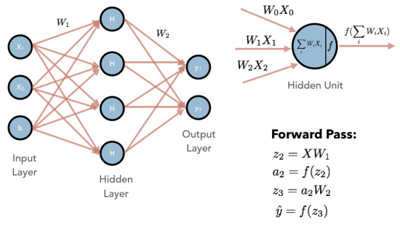

In [14]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/image/vanillaSoftMax.png", width=500,))

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VanillaSoftmaxSpeech(nn.Module):
    def __init__(self, n_frames=98, n_mfcc=40, n_classes=n_classes):
        super().__init__()
        self.in_features = n_frames * n_mfcc  # 98 * 40 = 3920
        self.fc = nn.Linear(self.in_features, n_classes)

    def forward(self, x):               # x peut être (batch, 1, 98, 40) ou (batch, 98, 40)
        if x.dim() == 4:                # (B, C, T, F) -> (B, T, F) si C=1
            x = x.squeeze(1)            # Aplatissement en vecteur
        x = x.reshape(x.size(0), -1)    # (B, 3920)
        logits = self.fc(x)             # (B, 30)
        return logits                   # CrossEntropyLoss fera softmax

### `2.1 Instanciation du modèle`

:::
`Lien avec la CrossEntropy`
La loss par exemple vaut : 
- $\small log(p_{true})$, où $p_{true}$ est la sortie softmax associée au label correct
- si $p_{true}$ est proche de 1, la loss est proche de 0
- si $p_{true}$ est très petite (quasi 0), la loss devient très grande
__Interprétation dans tes logs__.   
 - Lorsque la loss est importante pour un seul exemple, $p_{true}$ est quasiment nul pour ce point, 
   - cela signifie que le modèle est très sûr de la mauvaise classe.
 - Lorsque tous les batchs ont une loss 0, 
   - cela correspond au cas (numérique) où $p_{true}$≈1 partout, donc CrossEntropy ≈ 0.
:::     

In [ ]:
from torch.optim.lr_scheduler import LambdaLR

model_van = VanillaSoftmaxSpeech(n_frames=98, n_mfcc=40, n_classes=n_classes).to(device)
criterion = nn.CrossEntropyLoss()

n_params = sum(p.numel() for p in model_van.parameters())
print("Nb de paramètres :", n_params)

#optimizer = torch.optim.SGD( model_van.parameters(),lr=0.001, momentum=0.5, nesterov=True)
optimizer_van = torch.optim.AdamW(model_van.parameters(),lr=1e-3,weight_decay=1e-4)
optimizer = optimizer_van

Nb de paramètres : 23526


In [ ]:
num_epochs = 5
boundary = int(5 * num_epochs / 6)  # 5/6 du total

def lr_lambda(epoch):
    # epoch 0-4 : facteur 1.0 ; epoch >= 5 : facteur 0.1
    return 1.0 if epoch < boundary else 0.1

scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

### `2.2 Phase d'évaluation du modèle`

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

def eval_model(model, data_loader, criterion=None):
    model.eval()
    running_loss = 0.0
    y_true = []
    y_pred = []
    y_proba = []  # score/proba pour ROC/PR (binaire ou pour une classe donnée)

    with torch.no_grad():
        for mfcc, labels in data_loader:
            mfcc = mfcc.to(device)
            labels = labels.to(device)
            logits = model(mfcc)              # (B, n_classes)
            if criterion is not None:
                val_loss = criterion(logits, labels)
                running_loss += val_loss.item() * labels.size(0)

            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_proba.append(probs.cpu().numpy())

    val_acc = accuracy_score(y_true, y_pred)
    all_proba = np.concatenate(y_proba, axis=0)  # (N, n_classes)

    if criterion is not None:
        loss = running_loss / len(y_true)
        return val_loss, val_acc, y_true, y_pred, y_proba 
    else:
        return val_loss, val_acc, y_true, y_pred, y_proba

### `2.3 Fonction d'apprentissage`

In [18]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.preprocessing import label_binarize
import numpy as np
import torch


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    num_steps=3300,
    validate_every=40,
    patience=10,
    checkpoint_path="best_model.pt"
):
    global_step = 0
    epoch = 0

    train_losses = []
    train_accuracy = []

    val_losses = []
    val_accs = []
    val_precs = []
    val_recalls = []
    val_aucs = []
    val_pr_aucs = []
    val_fprs = []        # dicts: classe -> fpr
    val_tprs = []        # dicts: classe -> tpr
    val_pr_precs = []    # dicts: classe -> precision
    val_pr_recalls = []  # dicts: classe -> recall

    # ---- early stopping / best checkpoint ----
    best_auc = -np.inf
    since_best = 0

    while global_step < num_steps:
        epoch += 1
        running_loss = 0.0
        correct = 0
        total = 0

        for i, (mfcc, labels) in enumerate(train_loader):
            model.train()
            mfcc = mfcc.to(device)
            labels = labels.to(device)

            if global_step >= num_steps:
                break

            logits = model(mfcc)
            loss = criterion(logits, labels)

            proba = torch.softmax(logits, dim=1)
            num_classes = proba.shape[1]  # par ex. 6
            all_classes = np.arange(num_classes)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            global_step += 1

            batch_size = mfcc.size(0)
            running_loss += loss.item() * batch_size
            total += batch_size

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()

            # ---------- validation ----------
            if global_step % validate_every == 0:
                val_loss, val_acc, y_true, y_pred, y_proba = eval_model(model, val_loader, criterion) 

                # métriques de base
                prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
                rec = recall_score(y_true, y_pred, average="macro", zero_division=0)

                y_true_arr = np.array(y_true)
                y_proba_arr = np.array(y_proba)

                classes_present = np.unique(y_true_arr)
                y_proba_sub_norm = y_proba_arr[:, classes_present]
                y_true_bin = label_binarize(y_true_arr, classes=classes_present)

                # AUC ROC macro one-vs-rest sur toutes les classes
                auc_scores = []
                for i_cls, c in enumerate(all_classes):
                    y_true_c = (y_true_arr == c).astype(int)
                    y_score_c = y_proba_arr[:, i_cls]
                    if y_true_c.min() == 0 and y_true_c.max() == 1:
                        auc_c = roc_auc_score(y_true_c, y_score_c)
                        auc_scores.append(auc_c)

                auc_roc = np.mean(auc_scores) if len(auc_scores) > 0 else np.nan

                # AP macro multi-classe (sur les classes présentes)
                ap = average_precision_score(
                    y_true_arr,
                    y_proba_sub_norm,
                    average="macro",
                )

                # binarisation pour les courbes par classe
                y_true_bin = label_binarize(
                    y_true_arr,
                    classes=classes_present,
                )

                fprs = {}
                tprs = {}
                pr_precs = {}
                pr_recalls = {}

                for i_cls, c in enumerate(classes_present):
                    y_true_c = y_true_bin[:, i_cls]
                    y_score_c = y_proba_sub_norm[:, i_cls]

                    fpr_c, tpr_c, _ = roc_curve(y_true_c, y_score_c)
                    prec_c, rec_c, _ = precision_recall_curve(y_true_c, y_score_c)

                    fprs[c] = fpr_c
                    tprs[c] = tpr_c
                    pr_precs[c] = prec_c
                    pr_recalls[c] = rec_c

                # stockage
                val_losses.append(val_loss)
                val_accs.append(val_acc)
                val_precs.append(prec)
                val_recalls.append(rec)
                val_aucs.append(auc_roc)
                val_pr_aucs.append(ap)

                val_fprs.append(fprs)
                val_tprs.append(tprs)
                val_pr_precs.append(pr_precs)
                val_pr_recalls.append(pr_recalls)

                print(
                    f"[step {global_step}] "
                    f"val loss = {val_loss:.4f}, "
                    f"acc = {val_acc*100:.2f}%, "
                    f"prec = {prec*100:.2f}%, "
                    f"rec = {rec*100:.2f}%, "
                    f"AUC = {auc_roc:.3f}, "
                    f"AP = {ap:.3f}"
                )

                # ----- early stopping + checkpoint sur AUC -----
                if not np.isnan(auc_roc) and auc_roc > best_auc:
                    best_auc = auc_roc
                    since_best = 0
                    print(
                        f"New best AUC = {best_auc:.3f} at step {global_step}, "
                        f"saving checkpoint to {checkpoint_path}"
                    )
                    torch.save(model.state_dict(), checkpoint_path)
                else:
                    since_best += 1
                    if since_best >= patience:
                        print(
                            f"Early stopping triggered after no AUC improvement "
                            f"for {since_best} validations (best AUC = {best_auc:.3f})"
                        )
                        # retour anticipé : on sort proprement de la fonction
                        return (
                            train_losses,
                            train_accuracy,
                            val_losses,
                            val_accs,
                            val_precs,
                            val_recalls,
                            val_aucs,
                            val_pr_aucs,
                            val_fprs,
                            val_tprs,
                            val_pr_precs,
                            val_pr_recalls,
                        )

        # ---------- fin d’epoch ----------
        if total > 0:
            train_loss = running_loss / total
            train_acc = correct / total
            train_losses.append(train_loss)
            train_accuracy.append(train_acc)
            print(
                f"Epoch {epoch}: train loss = {train_loss:.4f} "
                f"train acc = {train_acc*100:.2f}%"
            )

        if scheduler is not None:
            scheduler.step()

    # fin normale (sans early stopping)
    return (
        train_losses,
        train_accuracy,
        val_losses,
        val_accs,
        val_precs,
        val_recalls,
        val_aucs,
        val_pr_aucs,
        val_fprs,
        val_tprs,
        val_pr_precs,
        val_pr_recalls,
    )

### `2.3 Apprentissage du modèle VanillaSoftMax`

#### `2.3.1 AUC (Area Under the ROC Curve)`

`AUC mesure si modèle classe bien les positifs au‑dessus des négatifs, indépendamment d’un seuil de décision.`

__`1. ROC et AUC, intuition`__

La courbe ROC trace :
 - axe x : Taux de faux positifs (FPR),
 - axe y : Taux de vrais positifs (TPR, sensibilité),

pour tous les seuils possibles sur le score du modèle.

`L’AUC ROC est l’aire sous cette courbe :`
 - AUC = 0.5 ≈ modèle aléatoire.
 - AUC = 1.0 = séparation parfaite (tous les positifs ont un score > tous les négatifs).

`Interprétation probabiliste :`
 - AUC = probabilité qu’un positif tiré au hasard ait un score plus élevé qu’un négatif tiré au hasard.

__`2. Binaire vs multi‑classe`__
 - Binaire : on applique ROC directement entre positive et negative.
 - Multi‑classe (comme ton KWS) :

on fait souvent du one‑vs‑rest par classe, puis on moyenne (macro) pour obtenir un AUC global.

`C’est exactement ce que tu fais dans le code :` pour chaque classe c, on construit un problème binaire « classe c vs le reste » et tu calcules un AUC, puis tu en fais la moyenne.

`3. Pourquoi est-ce intéressant:`
 - L’AUC est moins sensible au déséquilibre de classes que l’accuracy brute.
 - En KWS, cela dit si le modèle score bien les commandes correctes au‑dessus des autres sons (unknown, silence, autres commandes), - 
 - même si le seuil de décision n’est pas encore fixé.

In [ ]:
checkpoint_path = "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_model.pt"

train_losses_van, train_accuracy_van, val_losses_van,val_accs_van,val_precs_van,val_recalls_van, val_aucs_van, \
val_pr_aucs_van, val_fprs_van, val_tprs_van, val_pr_precs_van, val_pr_recalls_van = train_model(
                model=model_van,
                train_loader=train_loader,
                val_loader=val_loader,
                optimizer=optimizer,
                scheduler=scheduler, 
                criterion=criterion,
                num_steps=num_steps,
                validate_every=validate_every,
                patience=6,
                checkpoint_path="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_model.pt")

Epoch 1: train loss = 850.5470 train acc = 36.04%
[step 400] val loss = 936.1401, acc = 37.21%, prec = 49.84%, rec = 32.49%, AUC = 0.595, AP = 0.287
New best AUC = 0.595 at step 400, saving checkpoint to /Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_model.pt
Epoch 2: train loss = 494.5139 train acc = 47.02%
Epoch 3: train loss = 412.7611 train acc = 49.95%
[step 800] val loss = 592.7255, acc = 42.43%, prec = 50.63%, rec = 43.15%, AUC = 0.646, AP = 0.347
New best AUC = 0.646 at step 800, saving checkpoint to /Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_model.pt
Epoch 4: train loss = 353.3663 train acc = 54.33%
Epoch 5: train loss = 118.5361 train acc = 70.21%
[step 1200] val loss = 103.4184, acc = 70.23%, prec = 61.24%, rec = 57.00%, AUC = 0.838, AP = 0.613
New best AUC = 0.838 at step 1200, saving checkpoint to /Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_model.pt
Epoch 6: train loss = 93.3172 train acc = 71.18%


### `1.9 Test du modèle VanillaSoftMax`

In [ ]:
checkpoint_path="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_model.pt"

state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
model_van.load_state_dict(state_dict)   # pas de réassignation
model_van.to(device)
model_van.eval()

test_loss_van, test_acc_van, test_trues_van, test_preds_van, test_scores_van = eval_model(model_van, test_loader, criterion)
print(f"Final test loss = {test_loss_van:.4f}, test acc = {test_acc_van*100:.2f}%")

Final test loss = 21.7127, test acc = 69.29%


$$ \text{Accuracy} =  \frac{TP + TN}{TP + TN +FP + FN} \text{ .  Précision} = \frac{TP}{TP + FP} \text{ .  Recall} = \frac{TP}{TP + FN}$$

#### `Rapport complet + matrice de confusion`

$$ \text{Accuracy} =  \frac{TP + TN}{TP + TN +FP + FN} \text{ .  Précision} = \frac{TP}{TP + FP} \text{ .  Recall} = \frac{TP}{TP + FN}$$

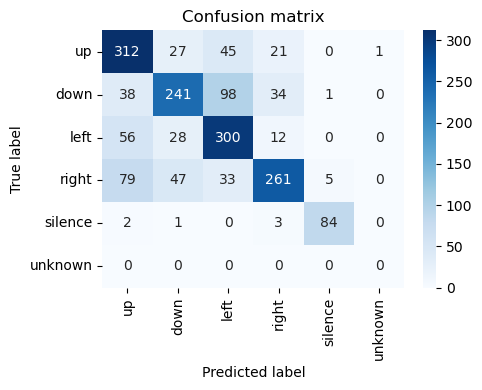

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns  # si tu l'as, sinon on peut faire sans
from sklearn.metrics import confusion_matrix

out_dir = "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/figures"
filename = "confusion_matrix__van.png"

# concaténation sûre du chemin
out_path = os.path.join(out_dir, filename)
cm = confusion_matrix(test_trues_van, test_preds_van)

class_names = ["up", "down", "left", "right", "silence", "unknown"]

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix VanillaSoftMax")
plt.tight_layout()
plt.savefig(out_path, dpi=300)  # ou un chemin complet
plt.show()


### __`1.9 Conclusion`__.  
La loss moyenne élevée (epoch 1) vient de quelques exemples catastrophiquement mal calibrés (proba quasi nulle sur la bonne classe), ce qui est exactement ce que la CrossEntropy est censée punir très fort. Une fois que le modèle s’est “verrouillé” sur la bonne classe (epoch 2), on obtient logiquement loss≈0 et acc=100 % sur le train.
Ces deux couples de valeurs val et test pour une loss qui remonte de 6.4 à 9.5 ne traduit pas une dégradation dramatique de la performance, mais une sensibilité de la CrossEntropy à quelques exemples « extrêmes ». Ils décrivent un modèle qui généralise très bien en termes d’accuracy, mais dont la CrossEntropy reste numériquement élevée à cause de quelques exemples très mal calibrés.

## `2. Deep Neuronal Network`
:::
L'Architecture du second modèle s'apppuie sur un réseau neuronal standard _fully connected_ avec 3 couches cachées et 128 nœuds cachés par couche utilisant la fonction d'activation RelU et du dropout Ce choix est du au fait que le RNN avec 3 hidden layers fully connected surpasse ceux à 1 ou 2, et qui se dégrade avec 4 ou plus. 
:::

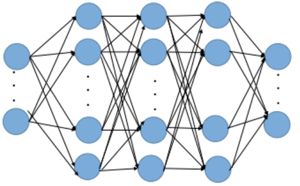

In [ ]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/image/dnn.png", width=400))

:::
 - L'augmentation du nombre de nœuds dans les couches cachées permet d'améliorer la précision, au détriment de risque d'overfitting, qui est compensé par la mise en place du dropout.

 - La fonction d'activation permet de briser la linéarité entre couche et le choix ReLU de limiter les problèmes de gradient tout en conservant une bonne capacité de modélisation.

 - Comparé à Vanilla Single Layer, ce modèle devrait donner un résultat plus précis au prix d'une plus grande empreinte mémoire et d'un coût de calcul plus élevé. 
:::

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SpeechDNN(nn.Module):
    def __init__(self, input_dim=98*40, hidden_dim=128, num_classes=n_classes, dropout_p=0.5):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, x):
        # x: (B, 98, 40) ou (B, 1, 98, 40)
        if x.dim() == 4:
            x = x.squeeze(1)        # (B, 98, 40)
        x = x.reshape(x.size(0), -1)  # (B, 3920)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        logits = self.out(x)         # (B, num_classes)
        return logits


In [ ]:
model_dnn = SpeechDNN(input_dim=98*40, hidden_dim=128, num_classes=n_classes, dropout_p=0.5).to(device)
criterion = nn.CrossEntropyLoss()

#optimizer = torch.optim.SGD(model_dnn.parameters(), lr=0.01, momentum=0.9)
optimizer_dnn = torch.optim.AdamW(model_van.parameters(),lr=1e-3,weight_decay=1e-4)
optimizer = optimizer_dnn

n_params = sum(p.numel() for p in model_dnn.parameters())
print("Nb de paramètres :", n_params)

Nb de paramètres : 535686


In [ ]:
checkpoint_path="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_dnn_model.pt"

train_losses_dnn, train_accuracy_dnn, val_losses_dnn,val_accs_dnn,val_precs_dnn,val_recalls_dnn, val_aucs_dnn, \
        val_pr_aucs_dnn, val_fprs_dnn, val_tprs_dnn, val_pr_precs_dnn, val_pr_recalls_dnn = train_model(
                model=model_dnn,
                train_loader=train_loader,
                val_loader=val_loader,
                optimizer=optimizer,
                scheduler=scheduler, 
                criterion=criterion,
                num_steps=num_steps,
                validate_every=validate_every,
                patience=6,
                checkpoint_path=checkpoint_path
                )

Epoch 1: train loss = 79517689263901364089615623913472.0000 train acc = 23.43%
[step 400] val loss = 1.5482, acc = 24.61%, prec = 4.92%, rec = 20.00%, AUC = 0.500, AP = 0.200
New best AUC = 0.500 at step 400, saving checkpoint to /Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_DNN_model.pt
Epoch 2: train loss = 1.5359 train acc = 23.98%
Epoch 3: train loss = 1.5264 train acc = 24.21%
[step 800] val loss = 1.5399, acc = 23.69%, prec = 4.74%, rec = 20.00%, AUC = 0.500, AP = 0.200
Epoch 4: train loss = 1.5223 train acc = 24.56%
Epoch 5: train loss = 1.5198 train acc = 24.29%
[step 1200] val loss = 1.5362, acc = 23.69%, prec = 4.74%, rec = 20.00%, AUC = 0.500, AP = 0.200
Epoch 6: train loss = 1.5184 train acc = 24.29%
Epoch 7: train loss = 1.5176 train acc = 24.26%
[step 1600] val loss = 1.5351, acc = 23.69%, prec = 4.74%, rec = 20.00%, AUC = 0.500, AP = 0.200
Epoch 8: train loss = 1.5164 train acc = 24.34%
Epoch 9: train loss = 1.5158 train acc = 24.12%
[step 2000] v

In [ ]:
state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
model_dnn.load_state_dict(state_dict)   # pas de réassignation
model_dnn.to(device)
model_dnn.eval()

test_loss_dnn, test_acc_dnn, test_trues_dnn, test_preds_dnn, test_scores_dnn = eval_model(model_dnn, test_loader, criterion)
print(f"Final test loss = {test_loss_dnn:.4f}, test acc = {test_acc_dnn*100:.2f}%")

Final test loss = 1.5374, test acc = 23.48%


## `III Convolution Neural Network CNN`

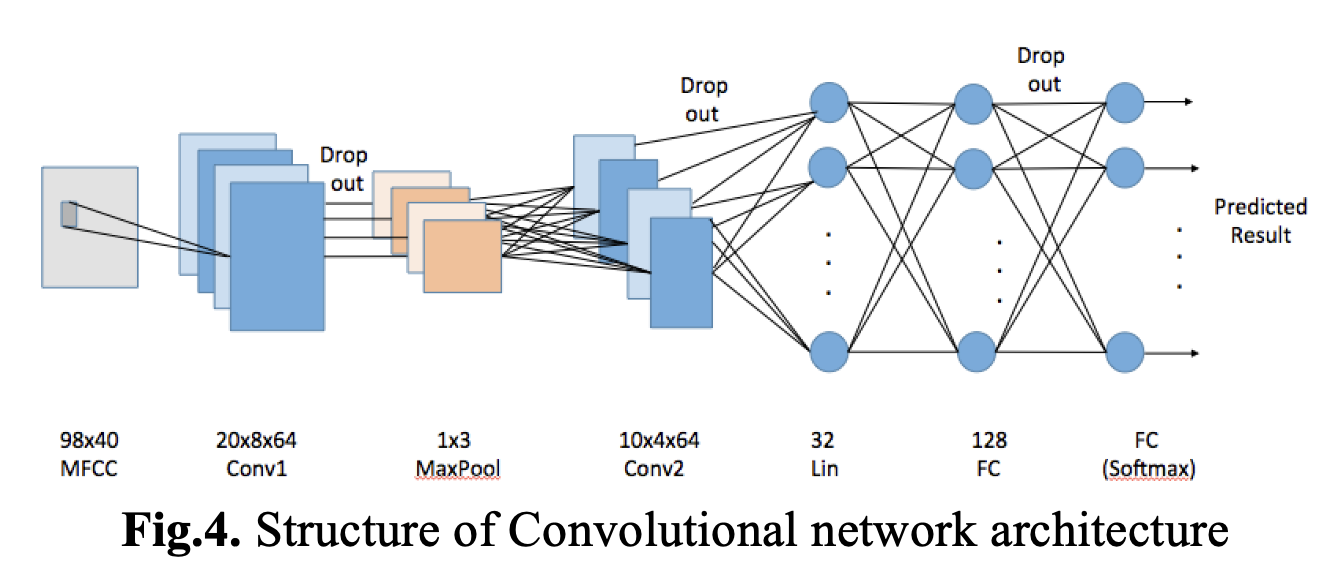

In [ ]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/image/cnn.png", width=800))

Voici un modèle PyTorch avec 2 convolutions, pooling, dropout, une couche linéaire de petite dimension, puis fully‑connected + softmax, avec un ordre de grandeur < 250 k paramètres pour des entrées MFCC (B,1,98,40).

N'est pas fait pour faire prendre en compte des séquences supérieurs à 1 seconde 

In [ ]:
class SimpleCNN_test(nn.Module):
    def __init__(
        self,
        n_classes,
        in_channels=1,
        base_channels=64,
        dropout_conv=0.2,
        dropout_fc=0.5,
    ):
        super().__init__()
        # 98x40 -> ~20x8 (stride (4,5))
        self.conv1 = nn.Conv2d(in_channels, base_channels, kernel_size=5,stride=(4, 5), padding=0)  # H: ~98/4 ≈ 24, W: ~40/5 = 8
        self.bn1   = nn.BatchNorm2d(base_channels)
        # 20x8 -> 10x4 (stride 2x2)
        self.conv2 = nn.Conv2d(base_channels, base_channels, kernel_size=3,stride=(2, 2), padding=1)
        self.bn2   = nn.BatchNorm2d(base_channels)

        # Pool (1x3) : 47x20 -> 47x~6–7, on veut ≈20x8 donc tu peux ajuster plus tard
        self.pool = nn.MaxPool2d(kernel_size=(1, 3), stride=(1, 3))
        self.drop_conv = nn.Dropout(dropout_conv)
        self.drop_fc   = nn.Dropout(dropout_fc)

        # calcul dynamique du flattened_dim
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 98, 40)
            x = self.pool(F.relu(self.bn1(self.conv1(dummy))))
            x = self.drop_conv(x)
            x = F.relu(self.bn2(self.conv2(x)))
            x = self.drop_conv(x)
            flattened_dim = x.view(1, -1).size(1)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(base_channels, 32)
        # 10x4x64 ≃ 2560 -> 32 -> 128 -> n_classes
        #self.fc1 = nn.Linear(flattened_dim, 32)     # "32 Lin" sur la figure
        self.fc2 = nn.Linear(32, 128)               # "128 FC"
        self.fc_out = nn.Linear(128, n_classes)     # FC(softmax)

    def forward(self, x):
        #print("in :", x.shape)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        #print("after conv1+pool :", x.shape)
        x = self.drop_conv(x)

        x = F.relu(self.bn2(self.conv2(x)))
        #print("after conv2 :", x.shape)        
        x = self.drop_conv(x)

        x = self.gap(x) 
        x = x.view(x.size(0), -1)
        #print("after flatten :", x.shape)
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = F.relu(self.fc2(x))
        x = self.drop_fc(x)
        return self.fc_out(x)

In [ ]:
class SimpleCNN_(nn.Module):
    def __init__(self, n_classes, in_channels=1,
                 base_channels=64,    # plus gros
                 hidden_dim=512,      # gros FC
                 dropout_conv=0.2, dropout_fc=0.5):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, base_channels,
                               kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(base_channels)

        self.conv2 = nn.Conv2d(base_channels, base_channels * 2,
                               kernel_size=3, padding=1)   # 128 canaux
        self.bn2   = nn.BatchNorm2d(base_channels * 2)

        self.pool = nn.MaxPool2d(2)
        self.gap  = nn.AdaptiveAvgPool2d((1, 1))

        self.drop_conv = nn.Dropout(dropout_conv)
        self.drop_fc   = nn.Dropout(dropout_fc)

        feat_dim = base_channels * 2            # 128
        self.fc_low = nn.Linear(feat_dim, 32)   # 32 Lin
        self.fc_mid = nn.Linear(32, hidden_dim) # 512 FC
        self.fc_out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.drop_conv(x)

        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.drop_conv(x)

        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_low(x))
        x = self.drop_fc(x)
        x = F.relu(self.fc_mid(x))
        x = self.drop_fc(x)
        return self.fc_out(x)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(
        self,
        n_classes,
        in_channels=1,
        base_channels=32,
        hidden_dim=128,
        dropout_conv=0.2,
        dropout_fc=0.5,
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(base_channels)

        self.conv2 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(base_channels * 2)

        self.pool = nn.MaxPool2d(2)
        self.drop_conv = nn.Dropout(dropout_conv)
        self.drop_fc   = nn.Dropout(dropout_fc)

        # calcul dynamique du flattened_dim
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 98, 40)
            x = self.pool(F.relu(self.bn1(self.conv1(dummy))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            flattened_dim = x.view(1, -1).size(1)

        self.fc_low = nn.Linear(flattened_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.drop_conv(x)

        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.drop_conv(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_low(x))
        x = self.drop_fc(x)
        return self.fc_out(x)

In [ ]:
model_cnn = SimpleCNN(n_classes,
                in_channels=1,
                base_channels=32,
                hidden_dim=128,
                dropout_conv=0.2,
                dropout_fc=0.5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.AdamW(model_van.parameters(),lr=1e-3,weight_decay=1e-4)
optimizer = optimizer_cnn
#optimizer = torch.optim.SGD(model_cnn.parameters(), lr=0.01, momentum=0.9)

n_params = sum(p.numel() for p in model_cnn.parameters())
print("Nb de paramètres :", n_params)

In [ ]:
checkpoint_path="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_cnn_model.pt"

train_losses_cnn, train_accuracy_cnn, val_losses_cnn,val_accs_cnn,val_precs_cnn,val_recalls_cnn, val_aucs_cnn, \
        val_pr_aucs_cnn, val_fprs_cnn, val_tprs_cnn, val_pr_precs_cnn, val_pr_recalls_cnn = train_model(
                model=model_cnn,
                train_loader=train_loader,
                val_loader=val_loader,
                optimizer=optimizer,
                scheduler=scheduler, 
                criterion=criterion,
                num_steps=num_steps,
                validate_every=validate_every,
                patience=6,
                checkpoint_path=checkpoint_path
                )

In [ ]:
import os
import matplotlib.pyplot as plt

def plot_metric(ax, x, y, title, ylabel, ylim=None):
    ax.plot(x, y, color="blue")
    ax.set_title(title)
    ax.set_xlabel("Training step")
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3)

def plot_all_metrics_for_model(model_name,
                               train_losses, val_losses,
                               train_accuracy, val_accs,
                               val_precs, val_recalls,
                               val_aucs, val_pr_aucs,
                               val_steps,
                               out_dir):
    plot_configs = [
        (range(len(train_losses)), train_losses,                      f"{model_name} - Train loss",    "Loss",          None),
        (val_steps,               val_losses,                         f"{model_name} - Val loss",      "Loss",          None),
        (range(len(train_accuracy)), [a*100 for a in train_accuracy], f"{model_name} - Train acc",     "Accuracy (%)",  (0, 100)),
        (val_steps,               [a*100 for a in val_accs],          f"{model_name} - Val acc",       "Accuracy (%)",  (0, 100)),
        (val_steps,               [p*100 for p in val_precs],         f"{model_name} - Val precision", "Precision (%)", (0, 100)),
        (val_steps,               [r*100 for r in val_recalls],       f"{model_name} - Val recall",    "Recall (%)",    (0, 100)),
        (val_steps,               val_aucs,                           f"{model_name} - ROC AUC",       "AUC",           (0, 1)),
        (val_steps,               val_pr_aucs,                        f"{model_name} - PR AUC",        "AP",            (0, 1)),
    ]

    n_plots = len(plot_configs)
    n_cols = 4
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.ravel()

    fig, ax = plt.subplots()

    ax.plot(validate_every, val_losses_van, label="Vanilla")
    ax.plot(validate_every, val_losses_dnn, label="DNN")
    ax.plot(validate_every, val_losses_cnn, label="CNN")

    ax.set_xlabel("Training step")
    ax.set_ylabel("Val loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


    for i, (x, y, title, ylabel, ylim) in enumerate(plot_configs):
        plot_metric(axes[i], x, y, title, ylabel, ylim)

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    os.makedirs(out_dir, exist_ok=True)
    filename = f"monitoring_{model_name}.png"
    out_path = os.path.join(out_dir, filename)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()


In [ ]:
def plot_val_loss_all_models(validate_every,
                             val_losses_van,
                             val_losses_dnn,
                             val_losses_cnn):
    fig, ax = plt.subplots()

    ax.plot(validate_every, val_losses_van, label="Vanilla")
    ax.plot(validate_every, val_losses_dnn, label="DNN")
    ax.plot(validate_every, val_losses_cnn, label="CNN")

    ax.set_xlabel("Training step")
    ax.set_ylabel("Val loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

plot_val_loss_all_models(
    validate_every,
    val_losses_van,
    val_losses_dnn,
    val_losses_cnn
)

In [ ]:
out_dir = "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/figures"

plot_all_metrics_for_model(
    "VanillaSoftmax",
    train_losses_van, val_losses_van,
    train_accuracy_van, val_accs_van,
    val_precs_van, val_recalls_van,
    val_aucs_van, val_pr_aucs_van,
    validate_every,
    out_dir
)

plot_all_metrics_for_model(
    "SpeechDNN",
    train_losses_dnn, val_losses_dnn,
    train_accuracy_dnn, val_accs_dnn,
    val_precs_dnn, val_recalls_dnn,
    val_aucs_dnn, val_pr_aucs_dnn,
    validate_every,
    out_dir
)

plot_all_metrics_for_model(
    "SimpleCNN",
    train_losses_cnn, val_losses_cnn,
    train_accuracy_cnn, val_accs_cnn,
    val_precs_cnn, val_recalls_cnn,
    val_aucs_cnn, val_pr_aucs_cnn,
    validate_every,
    out_dir
)
